In [1]:

import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

!pip install opencv-python matplotlib
!pip install -q segment_anything

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
CUDA is available: False


In [2]:


import os
from segment_anything import SamPredictor, sam_model_registry
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Choose a model type and download its checkpoint
sam_checkpoint = "sam_vit_b_01ec64.pth" # Using ViT-B checkpoint
model_type = "vit_b"

# Download the checkpoint if not already present
if not os.path.exists(sam_checkpoint):
    print(f"Downloading {sam_checkpoint}...")
    !wget https://dl.fbaipublicfiles.com/segment_anything/{sam_checkpoint}

# Initialize the SAM model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
# Move model to GPU if available
sam.to(device='cuda' if torch.cuda.is_available() else 'cpu')

predictor = SamPredictor(sam)

--2026-04-17 14:33:40--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.240.184.45, 54.240.184.75, 54.240.184.92, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.240.184.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   237MB/s    in 1.5s    

2026-04-17 14:33:42 (237 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



Saving FERRARI.jpeg to FERRARI.jpeg
User uploaded file "FERRARI.jpeg" with length 10448 bytes
Uploaded image name: FERRARI.jpeg
Using uploaded image: FERRARI.jpeg
Mask 1, Score: 0.903
Mask 2, Score: 0.900
Mask 3, Score: 0.326


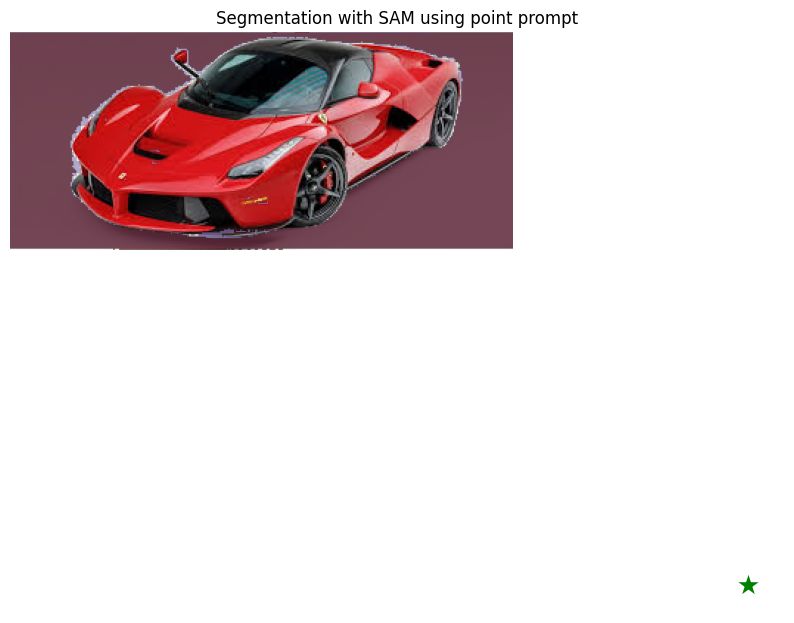

In [3]:

from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the user uploads only one image for segmentation
  # We can set this as the new image_name for the segmentation process
  uploaded_image_name = fn

print(f"Uploaded image name: {uploaded_image_name}")

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

# Use the uploaded image if available, otherwise use the default sample image
if 'uploaded_image_name' in globals() and os.path.exists(uploaded_image_name):
    image_to_segment = uploaded_image_name
    print(f"Using uploaded image: {image_to_segment}")
else:
    image_to_segment = "dog.jpg"
    if not os.path.exists(image_to_segment):
        print(f"Downloading {image_to_segment}...")
        # Using a verified working URL for the sample image
        !wget -O {image_to_segment} https://github.com/facebookresearch/segment-anything/blob/main/notebooks/images/dog.jpg?raw=true
    print(f"Using sample image: {image_to_segment}")

image = cv2.imread(image_to_segment)

# Add a check to ensure the image was loaded correctly
if image is None:
    print(f"Error: Could not load image from {image_to_segment}. Please check the file path or download URL.")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    predictor.set_image(image)

    # Define a point prompt (x, y) and its label (1 for foreground, 0 for background)
    # This point is roughly on the dog's head. Adjust for your image/object if needed.
    input_point = np.array([[500, 375]])
    input_label = np.array([1]) # 1 indicates a foreground point

    # Predict masks based on the point prompt
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

    # Visualize the results
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    for i, (mask, score) in enumerate(zip(masks, scores)):
        show_mask(mask, plt.gca(), random_color=True)
        print(f"Mask {i+1}, Score: {score:.3f}")
    show_points(input_point, input_label, plt.gca())
    plt.title("Segmentation with SAM using point prompt")
    plt.axis('off')
    plt.show()


Please upload your first image (e.g., a scene, an object).


Saving TOKYO.jpeg to TOKYO.jpeg
Uploaded image: TOKYO.jpeg
Images prepared successfully (uploaded image and a transformed version).
Image 1 shape: (181, 279), Image 2 shape: (181, 279)


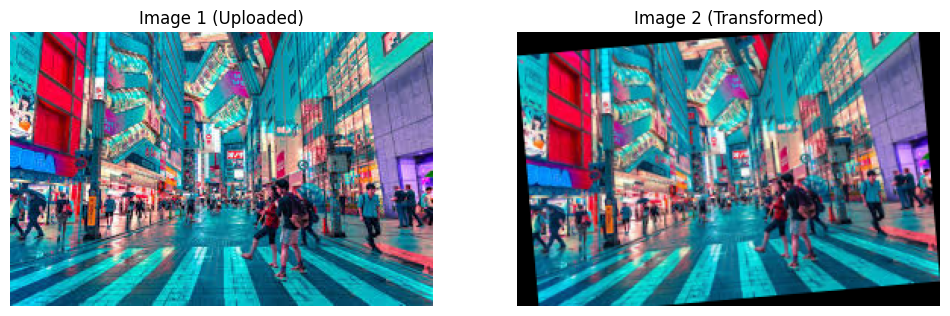

Keypoints found in Image 1: 422
Keypoints found in Image 2: 420


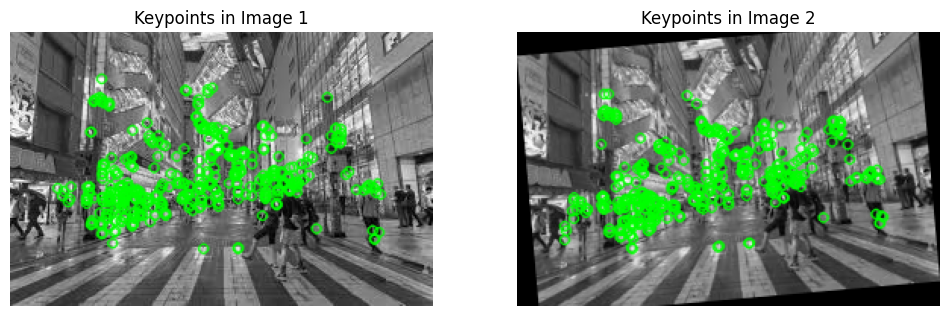

Total matches found: 266


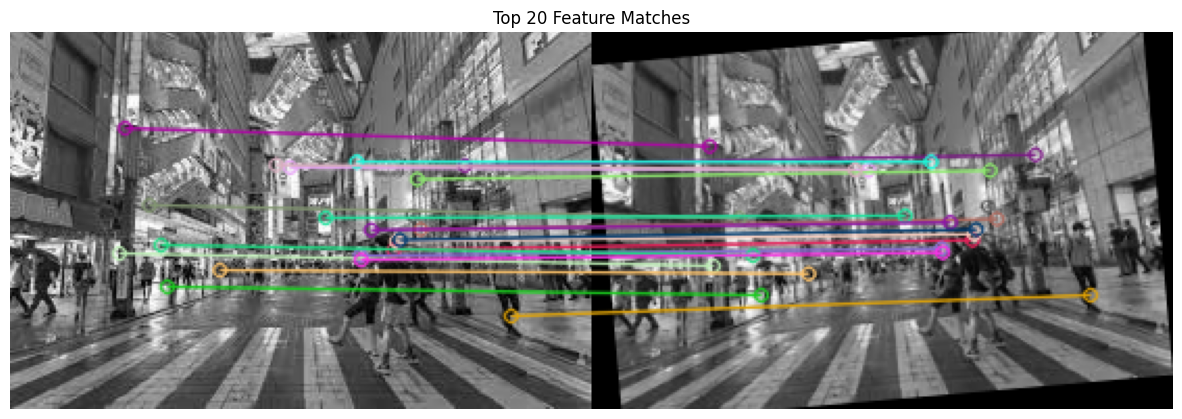

Fundamental Matrix:
 [[-3.30331632e-06  2.46589674e-04  1.52191788e-01]
 [-2.12268053e-04 -2.80610559e-05 -3.80514693e-03]
 [-1.49387492e-01 -1.37810390e-02  1.00000000e+00]]
Number of inliers: 260


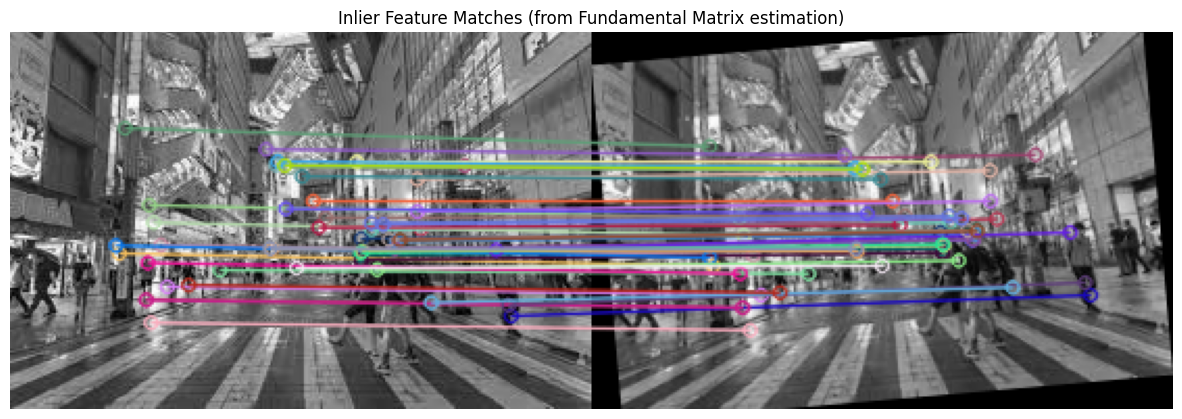


This workflow demonstrates feature detection, matching, and the estimation of the Fundamental Matrix – key initial steps in a visual SLAM pipeline. A complete SLAM system would build upon this by performing 3D reconstruction, tracking camera pose over many frames, optimizing the map and poses, and handling loop closures.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Allow user to upload an image
print("Please upload your first image (e.g., a scene, an object).")
uploaded = files.upload()

if not uploaded:
    print("No image uploaded. Please upload an image to proceed.")
else:
    # Assuming only one image is uploaded for simplicity
    uploaded_image_name = list(uploaded.keys())[0]
    print(f"Uploaded image: {uploaded_image_name}")

    # Load the uploaded image as color for display and then convert to grayscale
    img1_color = cv2.imread(uploaded_image_name)
    if img1_color is None:
        print(f"Error: Could not load {uploaded_image_name}. Please check the file format.")
    else:
        img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)

        # Create a second image (img2) by applying a slight transformation to img1
        # This simulates a second frame from a slightly moved camera
        rows, cols = img1.shape[:2]
        M = cv2.getRotationMatrix2D(((cols-1)/2.0, (rows-1)/2.0), 5, 0.95) # Rotate 5 degrees, scale 0.95
        img2_color = cv2.warpAffine(img1_color, M, (cols, rows))
        img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

        print("Images prepared successfully (uploaded image and a transformed version).")
        print(f"Image 1 shape: {img1.shape}, Image 2 shape: {img2.shape}")

        # Display images
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB)) # Display color for context
        axes[0].set_title('Image 1 (Uploaded)')
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)) # Display color for context
        axes[1].set_title('Image 2 (Transformed)')
        axes[1].axis('off')
        plt.show()




# Initialize ORB detector
orb = cv2.ORB_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print(f"Keypoints found in Image 1: {len(kp1)}")
print(f"Keypoints found in Image 2: {len(kp2)}")

# Optionally, draw keypoints to visualize
img_kp1 = cv2.drawKeypoints(img1, kp1, None, color=(0, 255, 0), flags=0)
img_kp2 = cv2.drawKeypoints(img2, kp2, None, color=(0, 255, 0), flags=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_kp1)
axes[0].set_title('Keypoints in Image 1')
axes[0].axis('off')
axes[1].imshow(img_kp2)
axes[1].set_title('Keypoints in Image 2')
axes[1].axis('off')
plt.show()



# Create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True) # NORM_HAMMING for ORB

# Match descriptors.
matches = bf.match(des1, des2)

# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)

print(f"Total matches found: {len(matches)}")

# Draw first 20 matches (for visualization purposes)
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 7))
plt.imshow(img_matches)
plt.title('Top 20 Feature Matches')
plt.axis('off')
plt.show()


# Extract matched keypoints
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Find the Fundamental Matrix
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 3.0, 0.99)

# F is the Fundamental Matrix, mask indicates inliers
print("Fundamental Matrix:\n", F)
print(f"Number of inliers: {np.sum(mask)}")

# We can also get the Essential Matrix if camera intrinsics are known
# For simplicity, we'll just show the Fundamental Matrix here.

# Filter inlier matches for visualization
inlier_matches = []
for i, m in enumerate(matches):
    if mask[i] == 1:
        inlier_matches.append(m)

img_inlier_matches = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 7))
plt.imshow(img_inlier_matches)
plt.title('Inlier Feature Matches (from Fundamental Matrix estimation)')
plt.axis('off')
plt.show()

print("\nThis workflow demonstrates feature detection, matching, and the estimation of the Fundamental Matrix – key initial steps in a visual SLAM pipeline. A complete SLAM system would build upon this by performing 3D reconstruction, tracking camera pose over many frames, optimizing the map and poses, and handling loop closures.")
